In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import figurefirst as fifi
###

import sys
sys.path.insert(1, '../../../Code')
from PlotUtilities import *
from FeatureFunctions import *


plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']

plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'


/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:92: SyntaxWarning: "is" with a literal. Did you mean "=="?
/home/flybot/anaconda3/envs/python3.11/lib/python3.11/site-packages/FlyPlotLib-0.0.1-py3.11.egg/fly_plot_lib/text.py:94: SyntaxWarning: "is" with a literal. Did you mean "=="?
2025-02-14 14:28:48,831 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 



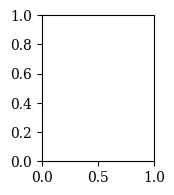

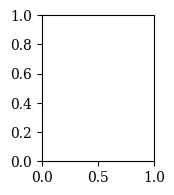

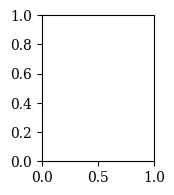

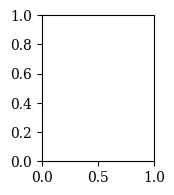

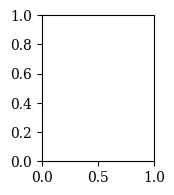

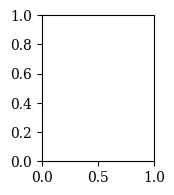

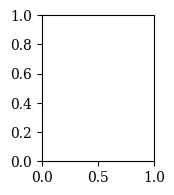

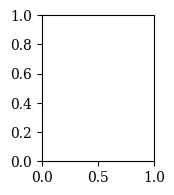

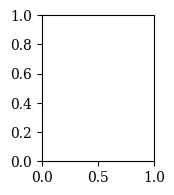

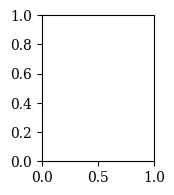

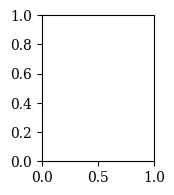

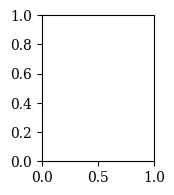

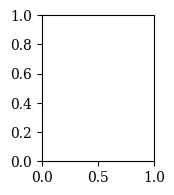

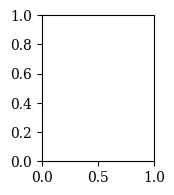

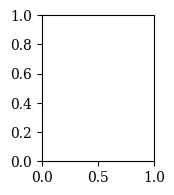

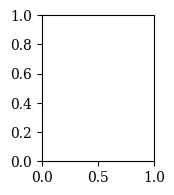

In [2]:
layout = fifi.svg_to_axes.FigureLayout('../../S2_aggstats.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])




# Bottom Half On

In [3]:
bottom_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_bottom_laminar_09092024.hdf')


In [4]:
bottom_on_df['ground speed'] = np.sqrt(bottom_on_df.xvel**2 + bottom_on_df.yvel**2)

In [5]:
df_flash_bottom_on = bottom_on_df[bottom_on_df.duration>0]
df_sham_bottom_on =bottom_on_df[bottom_on_df.duration==0]


In [6]:
flash_low_bottom_on = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_bottom_on  = df_flash_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

sham_low_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_bottom_on =df_sham_bottom_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

# Top Half On

In [7]:
top_on_df = pd.read_hdf('../../../Data/Experimental_Fly_Data/PreprocessedData/all_nights_new_processing_protocol_top_laminar_09092024.hdf')

In [8]:
top_on_df['ground speed'] = np.sqrt(top_on_df.xvel**2 + top_on_df.yvel**2)

In [9]:
df_flash_top_on = top_on_df[top_on_df.duration>0]
df_sham_top_on =top_on_df[top_on_df.duration==0]

In [10]:
flash_low_top_on = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
flash_up_top_on  = df_flash_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)


sham_low_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.max()<0.25)
sham_up_top_on =df_sham_top_on.groupby("obj_id_unique").filter(lambda d: d.z.min()>0.25)

# Altitude Organized Histplot of All Trajs

In [11]:
# pd.concat([ sham_up,  sham_low]).copy()
def traj_sorter(column):
    """Sort function"""
    
    meanzlist = dum_df[dum_df['time stamp'].between(0,675)].groupby('obj_id_unique').z.mean().sort_values(ascending=True).index
    locs = {traj: order for order, traj in enumerate(meanzlist)}
    return column.map(locs)


## Bottom Fans On

## Flash

In [12]:
df_flash = df_flash_bottom_on
df_flash_triggers = df_flash[df_flash.obj_id_unique.isin(df_flash[df_flash.Trigger_bool==True].obj_id_unique.unique())]
df_flash_triggers = df_flash_triggers.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
df_flash_triggers['abs_smooth_ang_vel'] = np.abs(df_flash_triggers.smoothed_angvel_params_128)

In [13]:
dum_df = df_flash_triggers
df_flash_sorted_by_z = dum_df.sort_values(by='obj_id_unique', key=traj_sorter)
df_flash_sorted_by_z['adj_heading'] = np.abs(df_flash_sorted_by_z['heading'].copy())



In [14]:
#fix index for plotting
df_flash_sorted_by_z['new_index']=0
j=1
catch =[]
means = []
for i in df_flash_sorted_by_z.obj_id_unique.unique():
    dum = df_flash_sorted_by_z[ df_flash_sorted_by_z.obj_id_unique==i]
    dum['new_index'] = j 
    #print('index:'+ str(dum['new_index'].iloc[0]) + ', mean z:' + str(np.mean(dum[dum['time stamp'].between(0,675)].z)) )
    j+=1
    catch.append(dum)
    means.append(np.mean(dum[dum['time stamp'].between(0,675)].z))
df_flash_sorted_by_z=pd.concat(catch)   


/tmp/ipykernel_10887/1160298079.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dum['new_index'] = j


/tmp/ipykernel_10887/2826452943.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right',)


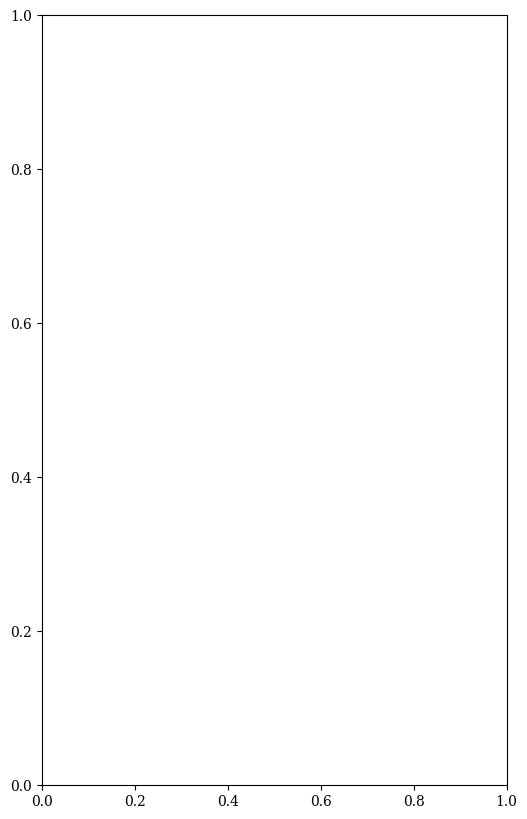

In [15]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='z')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('E1', 'e1')]

pc = ax.pcolormesh(test1, vmin=0, vmax=0.5, rasterized=True) 
clb=fig.colorbar(pc, location='right',)

#clb.set_ticks([0,0.1,.3.14], labels=['','upwind','downwind'],rotation=270)

#clb.ax.set_title('Altitude (m)', loc='right')

ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','','3'])
ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)
#ax.set_xlabel('Time, s')
fifi.mpl_functions.set_fontsize(ax, 6)

#
layout.append_figure_to_layer(layout.figures['E1'], 'E1', cleartarget=True)

/tmp/ipykernel_10887/2492658175.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


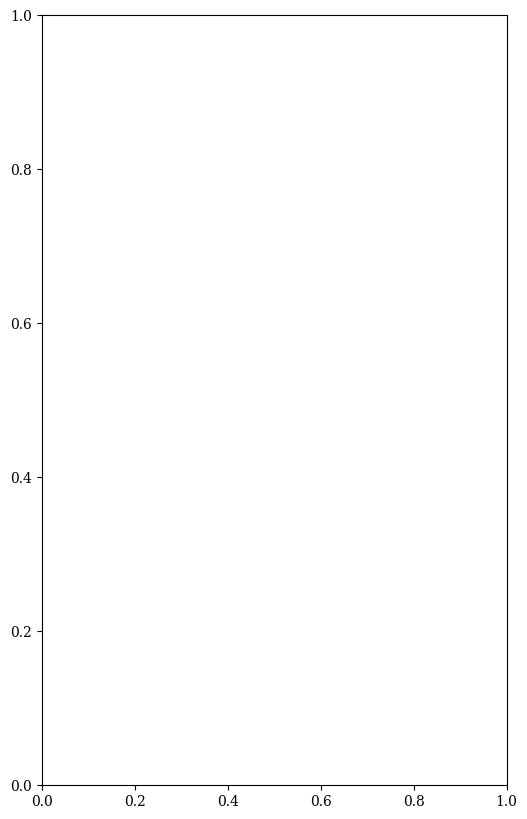

In [16]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='adj_heading')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('E2', 'e2')]

pc = ax.pcolormesh(test1, vmin=0, vmax=np.pi,   rasterized=True)
clb=fig.colorbar(pc, location='right')
clb.set_ticks([0,(np.pi/2),3.14], labels=['0','','$\pi$'])
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''],)
fifi.mpl_functions.set_fontsize(ax, 6)



layout.append_figure_to_layer(layout.figures['E2'], 'E2', cleartarget=True)

/tmp/ipykernel_10887/2210875354.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


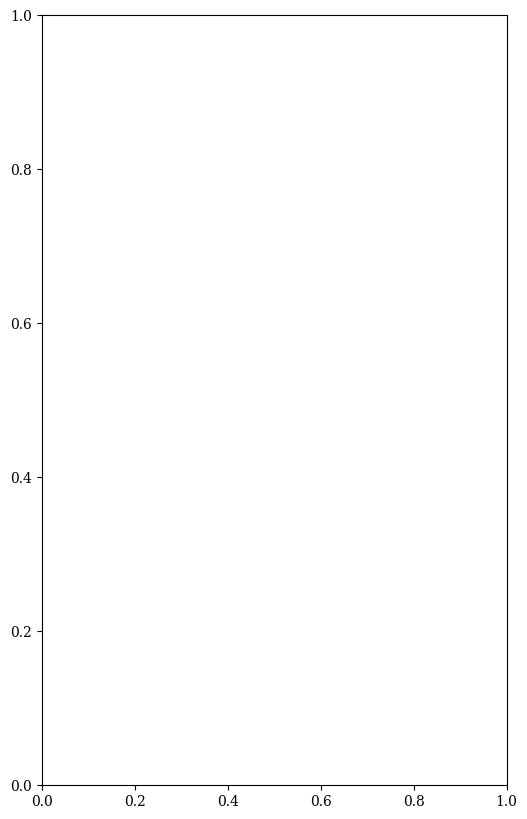

In [17]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='abs_smooth_ang_vel')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('E3', 'e3')]

pc = ax.pcolormesh(test1, vmin=0,vmax=20,  rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,3.14], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['E3'], 'E3', cleartarget=True)


/tmp/ipykernel_10887/3202551507.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


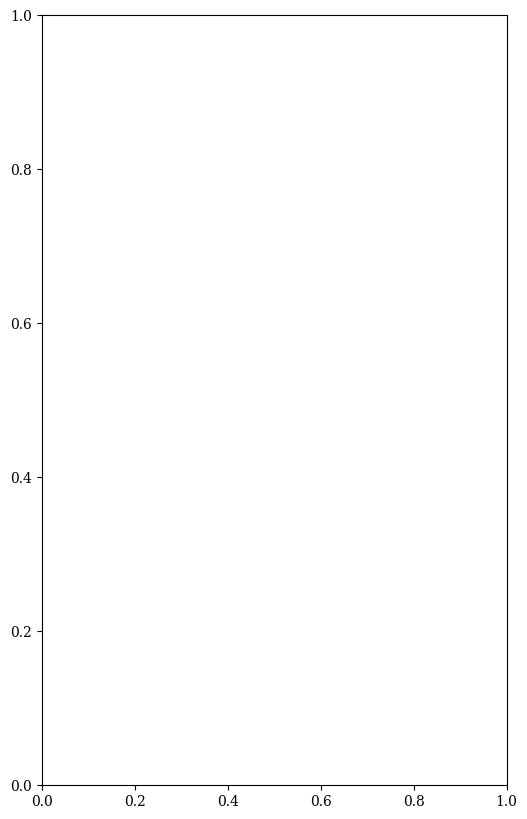

In [18]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='ground speed')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('E4', 'e4')]

pc = ax.pcolormesh(test1, vmin=0, vmax=1,   rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,1], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350], )
ax.set_xticklabels(['-0.5','0.0','0.68', '1','2','3'], rotation=45)
fifi.mpl_functions.set_fontsize(ax, 6)
ax.set_ylabel('Trajectory Number')
ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['E4'], 'E4', cleartarget=True)

## Shams

In [20]:
df_sham = df_sham_bottom_on
df_sham_triggers = df_sham[df_sham.obj_id_unique.isin(df_sham[df_sham.Trigger_bool==True].obj_id_unique.unique())]
df_sham_triggers = df_sham_triggers.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
df_sham_triggers['abs_smooth_ang_vel'] = np.abs(df_sham_triggers.smoothed_angvel_params_128)

In [21]:
dum_df = df_sham_triggers
df_sham_sorted_by_z = dum_df.sort_values(by='obj_id_unique', key=traj_sorter)
df_sham_sorted_by_z['adj_heading'] = np.abs(df_sham_sorted_by_z['heading'].copy())



In [22]:
#fix index for plotting
df_sham_sorted_by_z['new_index']=0
j=1
catch =[]
means = []
for i in df_sham_sorted_by_z.obj_id_unique.unique():
    dum = df_sham_sorted_by_z[ df_sham_sorted_by_z.obj_id_unique==i]
    dum['new_index'] = j 
    #print('index:'+ str(dum['new_index'].iloc[0]) + ', mean z:' + str(np.mean(dum[dum['time stamp'].between(0,675)].z)) )
    j+=1
    catch.append(dum)
    means.append(np.mean(dum[dum['time stamp'].between(0,675)].z))
df_sham_sorted_by_z=pd.concat(catch)    

/tmp/ipykernel_10887/623801160.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dum['new_index'] = j


/tmp/ipykernel_10887/3418388226.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right',)


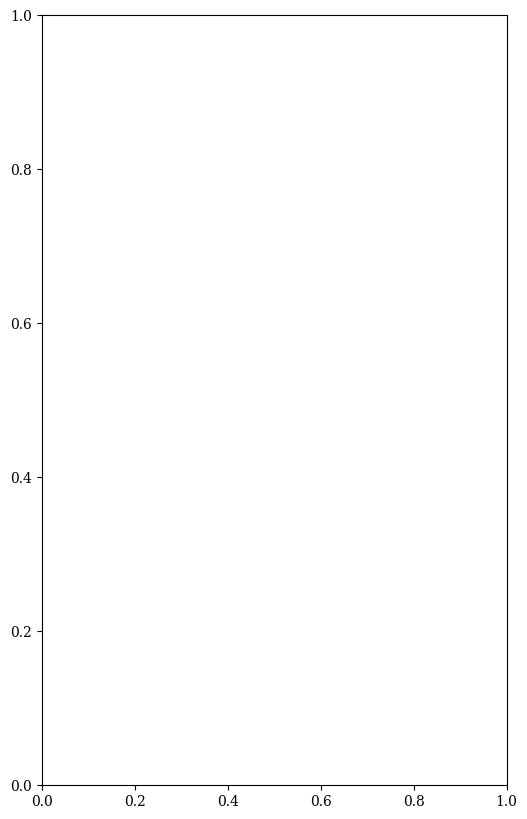

In [23]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='z')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('F1', 'f1')]

pc = ax.pcolormesh(test1, vmin=0, vmax=0.5,   rasterized=True) 
clb=fig.colorbar(pc, location='right',)

#clb.set_ticks([0,0.1,.3.14], labels=['','upwind','downwind'],rotation=270)

#clb.ax.set_title('Altitude (m)', loc='right')

ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','','3'])
ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)
#ax.set_xlabel('Time, s')
fifi.mpl_functions.set_fontsize(ax, 6)

#
layout.append_figure_to_layer(layout.figures['F1'], 'F1', cleartarget=True)

/tmp/ipykernel_10887/3136008873.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


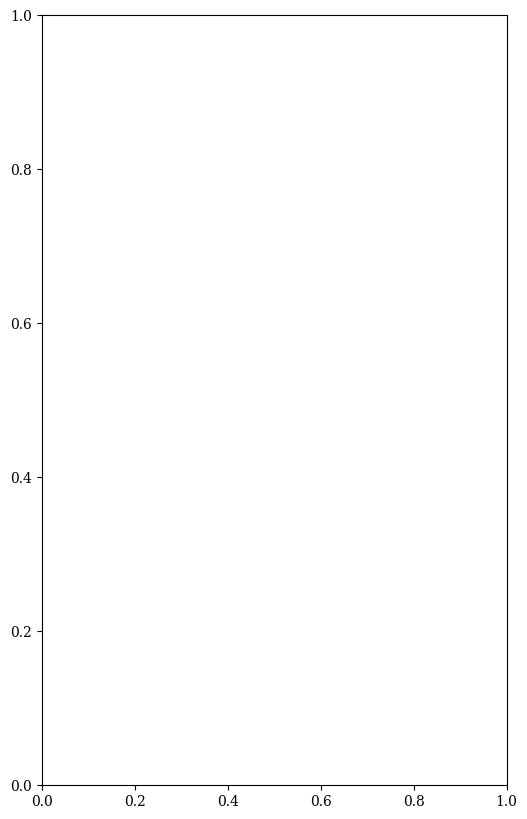

In [24]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='adj_heading')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('F2', 'f2')]

pc = ax.pcolormesh(test1, vmin=0, vmax=np.pi,   rasterized=True)
clb=fig.colorbar(pc, location='right')
clb.set_ticks([0,(np.pi/2),3.14], labels=['0','','$\pi$'])
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''],)
fifi.mpl_functions.set_fontsize(ax, 6)



layout.append_figure_to_layer(layout.figures['F2'], 'F2', cleartarget=True)

/tmp/ipykernel_10887/3626097713.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


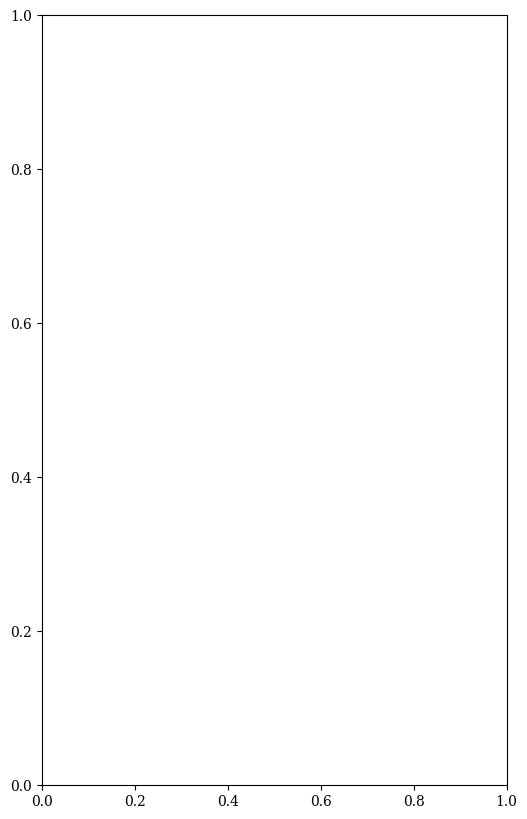

In [25]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='abs_smooth_ang_vel')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('F3', 'f3')]

pc = ax.pcolormesh(test1, vmin=0,vmax=20,  rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,3.14], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['F3'], 'F3', cleartarget=True)


/tmp/ipykernel_10887/2174818410.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


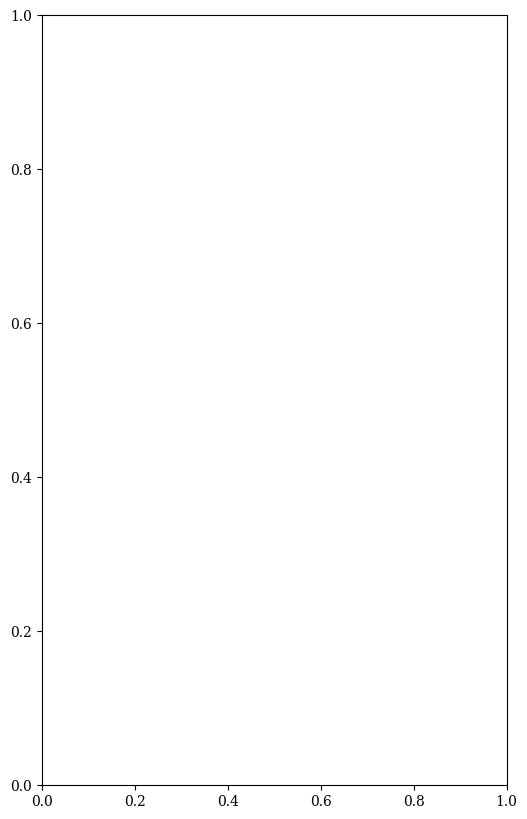

In [26]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='ground speed')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('F4', 'f4')]

pc = ax.pcolormesh(test1, vmin=0, vmax=1,   rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,1], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350], )
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['F4'], 'F4', cleartarget=True)

## Top Fans On

In [27]:
df_flash = df_flash_top_on
df_flash_triggers = df_flash[df_flash.obj_id_unique.isin(df_flash[df_flash.Trigger_bool==True].obj_id_unique.unique())]
df_flash_triggers = df_flash_triggers.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
df_flash_triggers['abs_smooth_ang_vel'] = np.abs(df_flash_triggers.smoothed_angvel_params_128)

In [28]:
dum_df = df_flash_triggers
df_flash_sorted_by_z = dum_df.sort_values(by='obj_id_unique', key=traj_sorter)
df_flash_sorted_by_z['adj_heading'] = np.abs(df_flash_sorted_by_z['heading'].copy())



In [29]:
#fix index for plotting
df_flash_sorted_by_z['new_index']=0
j=1
catch =[]
means = []
for i in df_flash_sorted_by_z.obj_id_unique.unique():
    dum = df_flash_sorted_by_z[ df_flash_sorted_by_z.obj_id_unique==i]
    dum['new_index'] = j 
    #print('index:'+ str(dum['new_index'].iloc[0]) + ', mean z:' + str(np.mean(dum[dum['time stamp'].between(0,675)].z)) )
    j+=1
    catch.append(dum)
    means.append(np.mean(dum[dum['time stamp'].between(0,675)].z))
df_flash_sorted_by_z=pd.concat(catch)   


/tmp/ipykernel_10887/1160298079.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dum['new_index'] = j


/tmp/ipykernel_10887/3830783898.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right',)


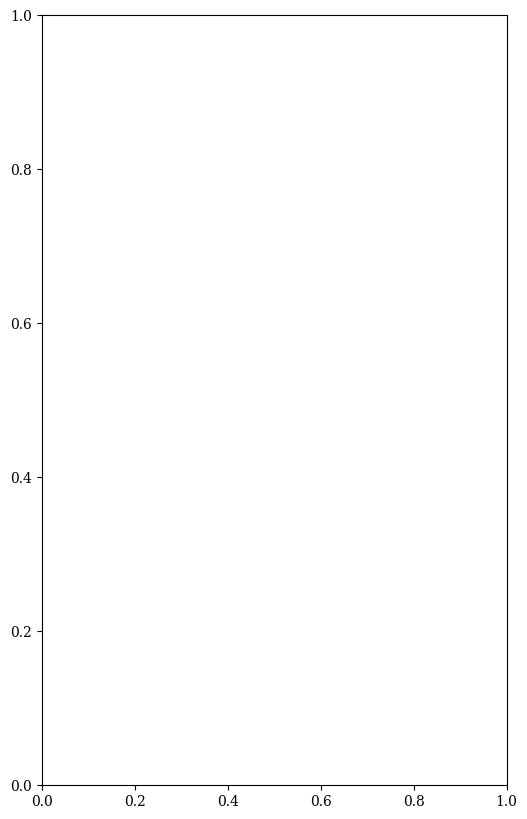

In [30]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='z')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('G1', 'g1')]

pc = ax.pcolormesh(test1, vmin=0, vmax=0.5,   rasterized=True) 
clb=fig.colorbar(pc, location='right',)

#clb.set_ticks([0,0.1,.3.14], labels=['','upwind','downwind'],rotation=270)

#clb.ax.set_title('Altitude (m)', loc='right')

ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','','3'])
ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)
#ax.set_xlabel('Time, s')
fifi.mpl_functions.set_fontsize(ax, 6)

#
layout.append_figure_to_layer(layout.figures['G1'], 'G1', cleartarget=True)

/tmp/ipykernel_10887/3894078999.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


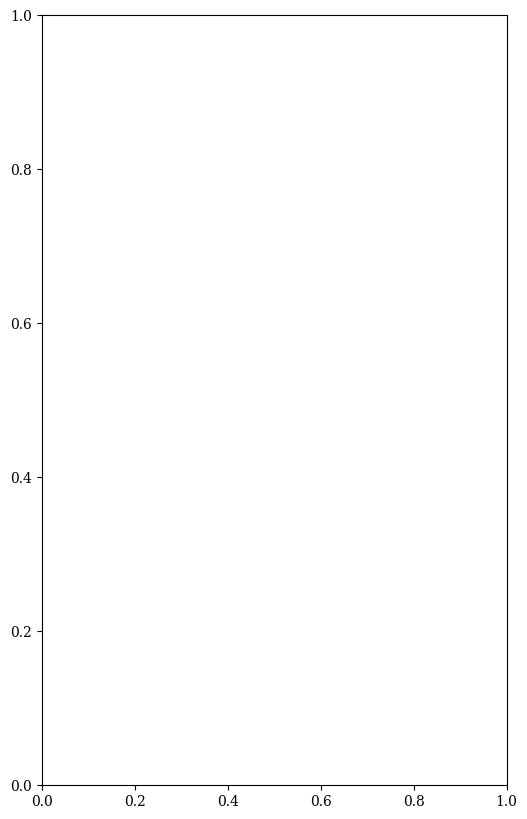

In [31]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='adj_heading')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('G2', 'g2')]

pc = ax.pcolormesh(test1, vmin=0, vmax=np.pi,   rasterized=True)
clb=fig.colorbar(pc, location='right')
clb.set_ticks([0,(np.pi/2),3.14], labels=['0','','$\pi$'])
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''],)
fifi.mpl_functions.set_fontsize(ax, 6)



layout.append_figure_to_layer(layout.figures['G2'], 'G2', cleartarget=True)

/tmp/ipykernel_10887/795497296.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


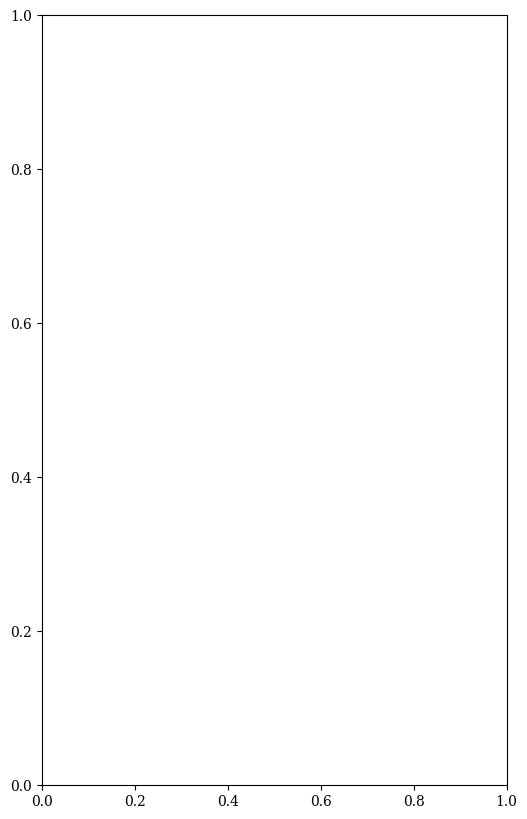

In [32]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='abs_smooth_ang_vel')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('G3', 'g3')]

pc = ax.pcolormesh(test1, vmin=0,vmax=20,  rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,3.14], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['G3'], 'G3', cleartarget=True)


/tmp/ipykernel_10887/3376485757.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


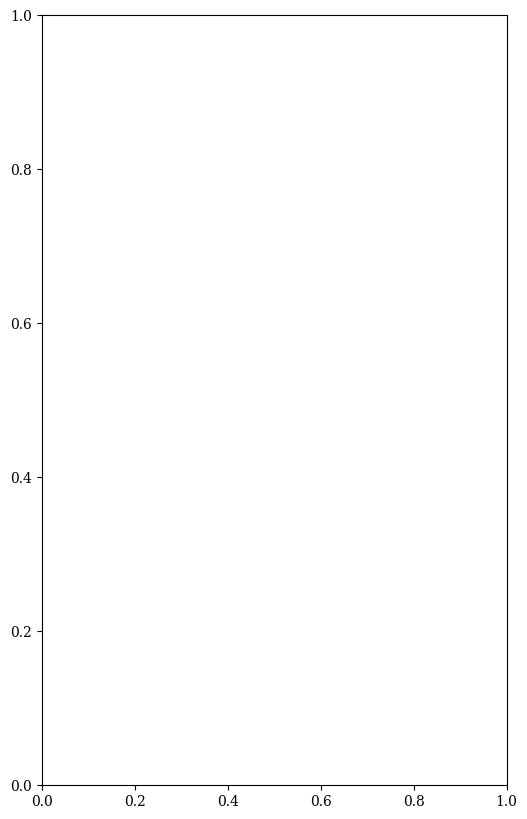

In [33]:
test1 = df_flash_sorted_by_z[df_flash_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='ground speed')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('G4', 'g4')]

pc = ax.pcolormesh(test1, vmin=0, vmax=1,   rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,1], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350], )
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['G4'], 'G4', cleartarget=True)

## Shams

In [34]:
df_sham = df_sham_top_on
df_sham_triggers = df_sham[df_sham.obj_id_unique.isin(df_sham[df_sham.Trigger_bool==True].obj_id_unique.unique())]
df_sham_triggers = df_sham_triggers.groupby('obj_id_unique').filter(lambda d: d['time stamp'].max()>=3000)
df_sham_triggers['abs_smooth_ang_vel'] = np.abs(df_sham_triggers.smoothed_angvel_params_128)

In [35]:
dum_df = df_sham_triggers
df_sham_sorted_by_z = dum_df.sort_values(by='obj_id_unique', key=traj_sorter)
df_sham_sorted_by_z['adj_heading'] = np.abs(df_sham_sorted_by_z['heading'].copy())



In [36]:
#fix index for plotting
df_sham_sorted_by_z['new_index']=0
j=1
catch =[]
means = []
for i in df_sham_sorted_by_z.obj_id_unique.unique():
    dum = df_sham_sorted_by_z[ df_sham_sorted_by_z.obj_id_unique==i]
    dum['new_index'] = j 
    #print('index:'+ str(dum['new_index'].iloc[0]) + ', mean z:' + str(np.mean(dum[dum['time stamp'].between(0,675)].z)) )
    j+=1
    catch.append(dum)
    means.append(np.mean(dum[dum['time stamp'].between(0,675)].z))
df_sham_sorted_by_z=pd.concat(catch)    

/tmp/ipykernel_10887/623801160.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dum['new_index'] = j


/tmp/ipykernel_10887/1103051757.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right',)


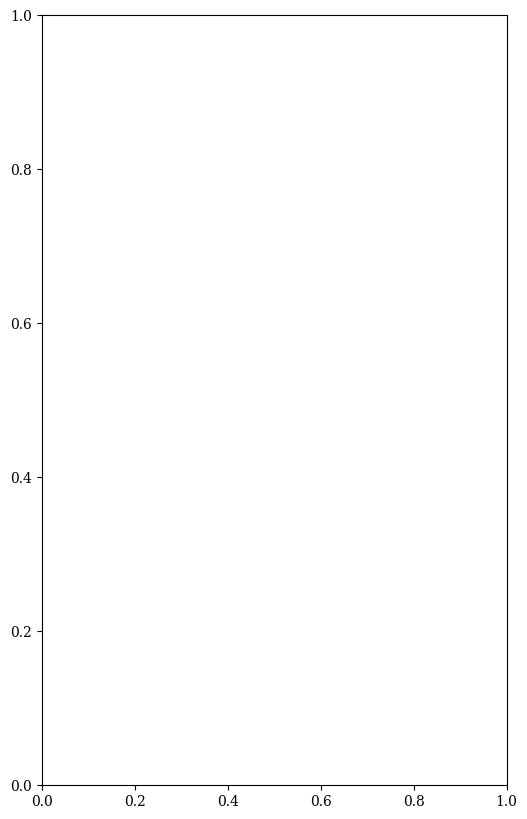

In [37]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='z')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('H1', 'h1')]

pc = ax.pcolormesh(test1, vmin=0, vmax=0.5,   rasterized=True) 
clb=fig.colorbar(pc, location='right',)

#clb.set_ticks([0,0.1,.3.14], labels=['','upwind','downwind'],rotation=270)

#clb.ax.set_title('Altitude (m)', loc='right')

ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','','3'])
ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)
#ax.set_xlabel('Time, s')
fifi.mpl_functions.set_fontsize(ax, 6)

#
layout.append_figure_to_layer(layout.figures['H1'], 'H1', cleartarget=True)

/tmp/ipykernel_10887/223458207.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


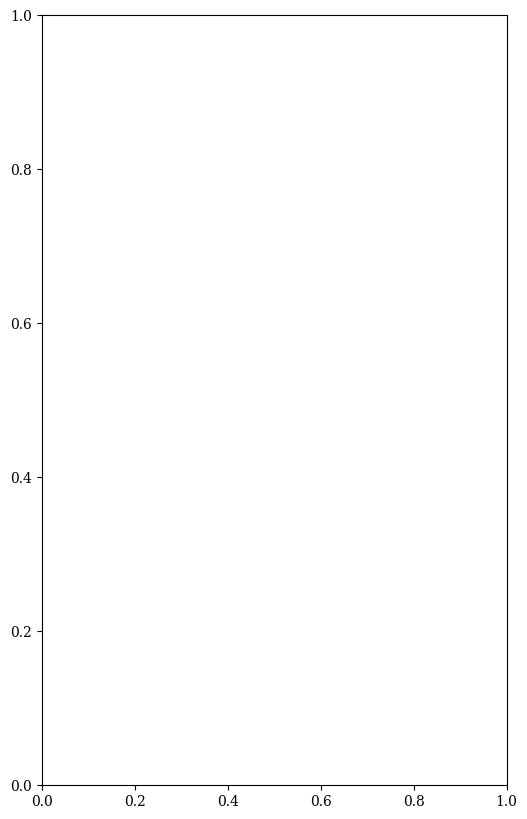

In [38]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='adj_heading')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('H2', 'h2')]

pc = ax.pcolormesh(test1, vmin=0, vmax=np.pi,   rasterized=True)
clb=fig.colorbar(pc, location='right')
clb.set_ticks([0,(np.pi/2),3.14], labels=['0','','$\pi$'])
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''],)
fifi.mpl_functions.set_fontsize(ax, 6)



layout.append_figure_to_layer(layout.figures['H2'], 'H2', cleartarget=True)

/tmp/ipykernel_10887/3325219581.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


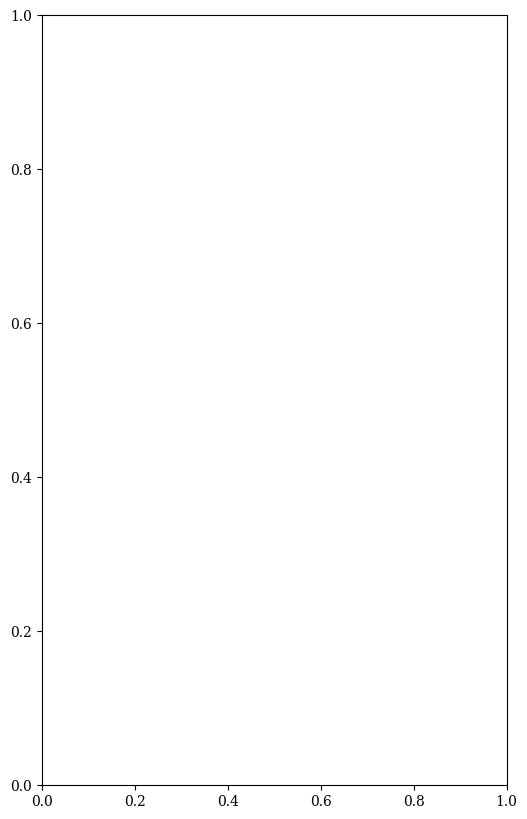

In [39]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='abs_smooth_ang_vel')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('H3', 'h3')]

pc = ax.pcolormesh(test1, vmin=0,vmax=20,  rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,3.14], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350])
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['H3'], 'H3', cleartarget=True)


/tmp/ipykernel_10887/2971514615.py:6: UserWarning: Adding colorbar to a different Figure <Figure size 850x1100 with 2 Axes> than <Figure size 600x1000 with 1 Axes> which fig.colorbar is called on.
  clb=fig.colorbar(pc, location='right')


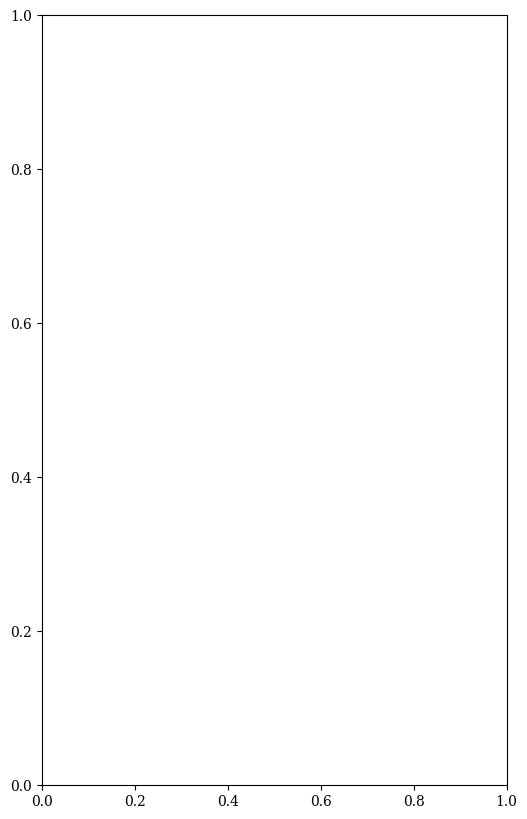

In [40]:
test1 = df_sham_sorted_by_z[df_sham_sorted_by_z['time stamp'].between(-500,3000)].pivot(index='new_index', columns='time stamp', values='ground speed')#.dropna()
fig, ax = plt.subplots(figsize=(6,10))
ax = layout.axes[('H4', 'h4')]

pc = ax.pcolormesh(test1, vmin=0, vmax=1,   rasterized=True)
clb=fig.colorbar(pc, location='right')
#clb.set_ticks([0,1], labels=['upwind','downwind'],rotation=270)
ax.axhline(np.median(np.where((np.array(means)>0.249) & (np.array(means)<0.251) )), color='grey', linestyle='dotted') 

ax.set_yticks([0,500,1000])
ax.set_yticklabels([0,500,1000],rotation=45)

ax.set_xticks([0,50,50+68, 150, 250,350], )
ax.set_xticklabels(['','0','', '','',''])
fifi.mpl_functions.set_fontsize(ax, 6)
#ax.set_ylabel('Trajectory Number')
#ax.set_xlabel('Time (s)')

layout.append_figure_to_layer(layout.figures['H4'], 'H4', cleartarget=True)

In [41]:
layout.write_svg('S2_all.svg')